# Traveling Salesman Problem (TSP) — Problem Visualization

Notebook này trực quan hóa **Bài toán Người bán hàng du lịch (TSP)** — một trong những bài toán tối ưu tổ hợp kinh điển nhất.

$$\min \; f(\mathbf{x}) = \sum_{i=1}^{n} \sum_{\substack{j=1 \\ j \neq i}}^{n} d_{ij} \cdot x_{ij}$$

Các hình minh họa bao gồm:
1. **Bố trí thành phố** trên mặt phẳng 2D
2. **Đồ thị đầy đủ** — tất cả các cạnh có thể
3. **Không gian tìm kiếm** — độ phức tạp giai thừa
4. **So sánh các tour** — ngẫu nhiên vs. tham lam lân cận gần nhất
5. **Ma trận khoảng cách** — heatmap trực quan
6. **Cấu trúc lân cận 2-opt** — minh họa hoán vị

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
if not os.path.isdir(os.path.join(sys.path[0], 'AIP')):
    sys.path[0] = os.path.join(os.getcwd(), 'src')

import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# ── Reproducible city layout ────────────────────────────────────────────────
np.random.seed(42)
N = 10
coords = np.random.rand(N, 2) * 100
city_names = [f'C{i}' for i in range(N)]

# Euclidean distance matrix
diff = coords[:, None, :] - coords[None, :, :]
dist_matrix = np.sqrt((diff ** 2).sum(axis=-1))

# ── Helper functions ─────────────────────────────────────────────────────────
def draw_tour(ax, coords, tour, color='steelblue', lw=2, arrow=True):
    n = len(tour)
    for k in range(n):
        i, j = tour[k], tour[(k + 1) % n]
        xi, yi = coords[i]
        xj, yj = coords[j]
        if arrow:
            ax.annotate('', xy=(xj, yj), xytext=(xi, yi),
                        arrowprops=dict(arrowstyle='->', color=color,
                                        lw=lw, mutation_scale=15))
        else:
            ax.plot([xi, xj], [yi, yj], color=color, lw=lw, zorder=2)

def tour_length(dist_matrix, tour):
    return sum(dist_matrix[tour[k], tour[(k + 1) % len(tour)]]
               for k in range(len(tour)))

def nearest_neighbor_tour(dist_matrix, start=0):
    n = len(dist_matrix)
    unvisited = list(range(n))
    tour = [start]
    unvisited.remove(start)
    while unvisited:
        current = tour[-1]
        nearest = min(unvisited, key=lambda x: dist_matrix[current, x])
        tour.append(nearest)
        unvisited.remove(nearest)
    return tour

# ── Figure output directory ──────────────────────────────────────────────────
os.makedirs('figures', exist_ok=True)

print('Setup OK — N =', N, 'cities')
print('City coords (first 3):', coords[:3].round(2))


Setup OK — N = 10 cities
City coords (first 3): [[37.45 95.07]
 [73.2  59.87]
 [15.6  15.6 ]]


## 1. Bố trí thành phố — Cities on a Map

Cho tập $n$ thành phố ngẫu nhiên trên mặt phẳng 2D. Mỗi thành phố là một điểm $(x_i, y_i)$.  
Bài toán TSP yêu cầu tìm **một vòng kín** đi qua tất cả thành phố **đúng một lần** và quay về điểm xuất phát.

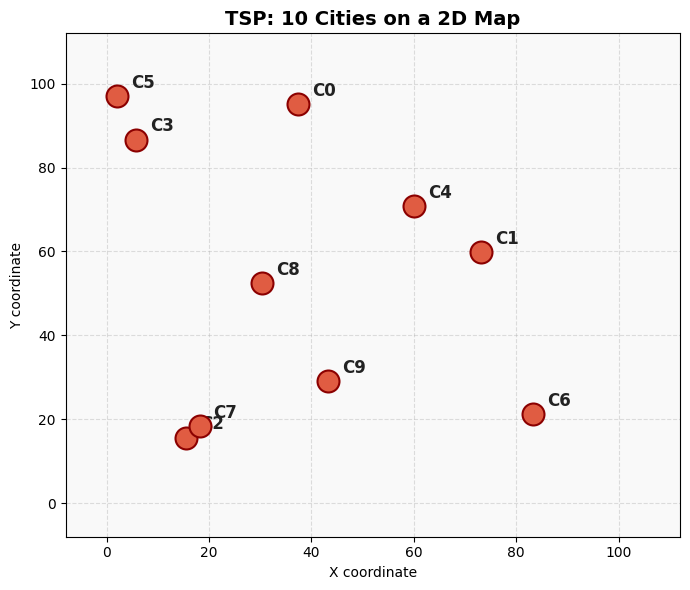

Saved → figures/tsp_cities.png


In [2]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(coords[:, 0], coords[:, 1],
           s=250, c='#e05c42', zorder=5, edgecolors='#8b0000', linewidths=1.5)

for i, (x, y) in enumerate(coords):
    ax.annotate(city_names[i], (x, y),
                textcoords='offset points', xytext=(10, 6),
                fontsize=12, fontweight='bold', color='#222')

ax.set_xlim(-8, 112)
ax.set_ylim(-8, 112)
ax.set_title(f'TSP: {N} Cities on a 2D Map', fontsize=14, fontweight='bold')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('figures/tsp_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/tsp_cities.png')


## 2. Đồ thị đầy đủ — All Possible Connections

Trong TSP, ta xét **đồ thị đầy đủ** $K_n$: mỗi cặp thành phố đều được kết nối bởi một cạnh với trọng số $d_{ij}$.  
Với $n$ thành phố, có $\binom{n}{2} = \frac{n(n-1)}{2}$ cạnh — tất cả đều là lựa chọn tiềm năng cho tour.

Bài toán TSP yêu cầu chọn một **tập con cạnh** tạo thành đúng một vòng Hamiltonian.

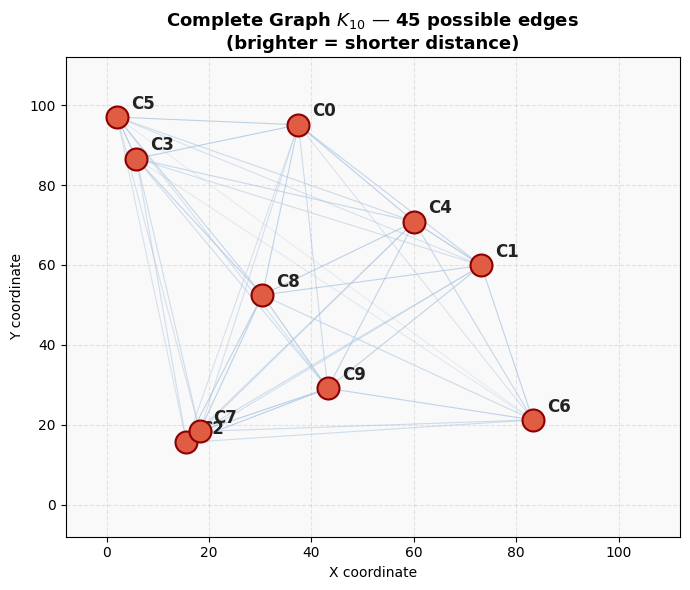

Saved → figures/tsp_complete_graph.png
K_10: 45 edges total


In [3]:
fig, ax = plt.subplots(figsize=(7, 6))

# Draw all edges (complete graph) with weight-based alpha
max_d = dist_matrix.max()
for i in range(N):
    for j in range(i + 1, N):
        alpha = 1.0 - 0.75 * (dist_matrix[i, j] / max_d)
        ax.plot([coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color='#aac4e0', lw=0.8, alpha=alpha, zorder=1)

ax.scatter(coords[:, 0], coords[:, 1],
           s=250, c='#e05c42', zorder=5, edgecolors='#8b0000', linewidths=1.5)

for i, (x, y) in enumerate(coords):
    ax.annotate(city_names[i], (x, y),
                textcoords='offset points', xytext=(10, 6),
                fontsize=12, fontweight='bold', color='#222')

n_edges = N * (N - 1) // 2
ax.set_xlim(-8, 112)
ax.set_ylim(-8, 112)
ax.set_title(f'Complete Graph $K_{{{N}}}$ — {n_edges} possible edges\n'
             f'(brighter = shorter distance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('figures/tsp_complete_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → figures/tsp_complete_graph.png')
print(f'K_{N}: {n_edges} edges total')


## 3. Không gian tìm kiếm — Factorial Search Space

Số lượng tour phân biệt (không kể chiều đi) trong bài toán TSP *đối xứng* là:

$$|\mathcal{S}| = \frac{(n-1)!}{2}$$

Đây là sự **bùng nổ giai thừa** — với $n = 20$ thành phố đã có hơn **60 nghìn tỷ** tour khả dĩ.

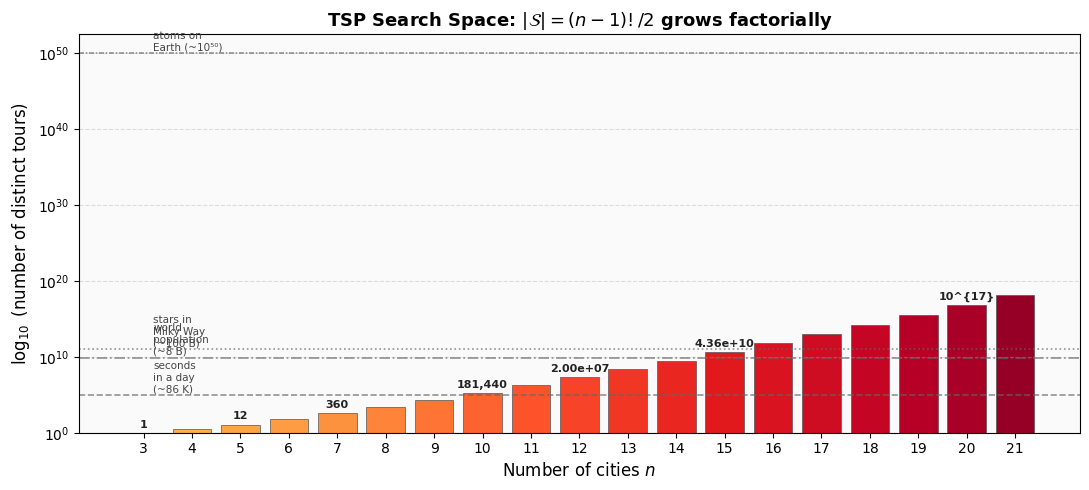

Saved → figures/tsp_search_space.png
  n= 3  tours = 1
  n= 5  tours = 12
  n=10  tours = 181,440
  n=15  tours = 43,589,145,600
  n=20  tours = 60,822,550,204,416,000


In [4]:
ns = list(range(3, 22))
num_tours = [math.factorial(n - 1) // 2 for n in ns]

# ── Reference scale markers ──────────────────────────────────────────────────
refs = {
    'seconds\nin a day\n(~86 K)':    86_400,
    'world\npopulation\n(~8 B)':      8e9,
    'stars in\nMilky Way\n(~100 B)':  1e11,
    'atoms on\nEarth (~10⁵⁰)':       1e50,
}

fig, ax = plt.subplots(figsize=(11, 5))

colors = plt.cm.YlOrRd(np.linspace(0.35, 0.95, len(ns)))
bars = ax.bar(ns, np.log10([max(t, 1) for t in num_tours]), color=colors,
              edgecolor='#555', linewidth=0.5)

# Annotate a few bars with actual numbers
label_ns = [3, 5, 7, 10, 12, 15, 20]
for n, t in zip(ns, num_tours):
    if n in label_ns:
        log_val = math.log10(max(t, 1))
        if t < 1e6:
            label = f'{t:,}'
        elif t < 1e12:
            label = f'{t:.2e}'
        else:
            label = f'10^{{{int(round(log_val))}}}'
        ax.text(n, log_val + 0.4, label, ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#222')

# Reference lines
line_styles = ['--', '-.', ':', (0, (3, 1, 1, 1))]
for (label, val), ls in zip(refs.items(), line_styles):
    lv = math.log10(val)
    ax.axhline(lv, color='#666', lw=1.2, linestyle=ls, alpha=0.7)
    ax.text(3.2, lv + 0.15, label, fontsize=7.5, color='#444',
            va='bottom', ha='left')

ax.set_xlabel('Number of cities $n$', fontsize=12)
ax.set_ylabel('$\\log_{10}$ (number of distinct tours)', fontsize=12)
ax.set_title('TSP Search Space: $|\\mathcal{S}| = (n-1)!/2$ grows factorially',
             fontsize=13, fontweight='bold')
ax.set_xticks(ns)
ax.set_xticklabels([str(n) for n in ns])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'$10^{{{int(x)}}}$'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('figures/tsp_search_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/tsp_search_space.png')
for n, t in zip(ns, num_tours):
    if n in [3, 5, 10, 15, 20]:
        print(f'  n={n:2d}  tours = {t:,.0f}')


## 4. So sánh các Tour — Random vs. Nearest-Neighbor

Để thấy rõ sự khác biệt giữa một **tour ngẫu nhiên** (xây dựng không có chiến lược) và **tour tham lam lân cận gần nhất** (*Nearest-Neighbor Heuristic*):

- **Random tour**: chọn thứ tự thành phố ngẫu nhiên → thường cho kết quả rất xấu
- **Nearest-Neighbor**: từ thành phố hiện tại, luôn đi đến thành phố **chưa thăm gần nhất**

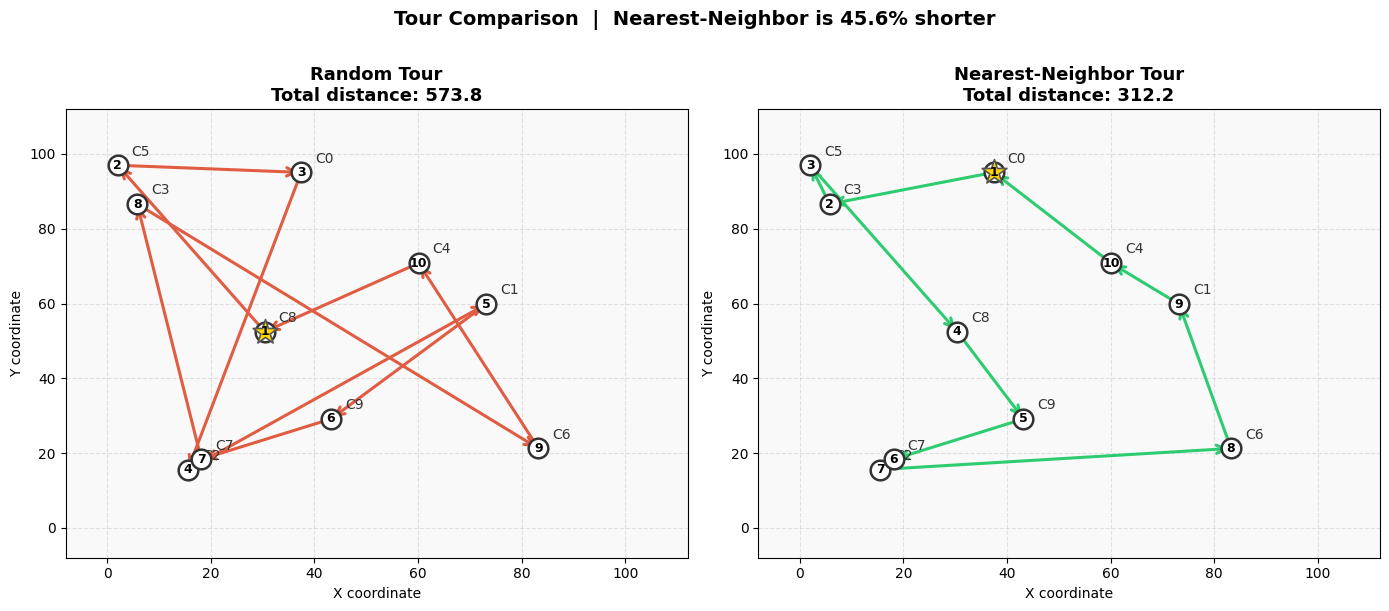

Saved → figures/tsp_tour_comparison.png
Random:          573.8
Nearest-Neighbor:312.2
Improvement:     45.6%


In [5]:
np.random.seed(7)
random_tour = list(np.random.permutation(N))
greedy_tour = nearest_neighbor_tour(dist_matrix, start=0)

dist_random = tour_length(dist_matrix, random_tour)
dist_greedy = tour_length(dist_matrix, greedy_tour)

# ── Side-by-side tours ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tour, title, color, dist in [
    (axes[0], random_tour,  'Random Tour',            '#e05c42', dist_random),
    (axes[1], greedy_tour,  'Nearest-Neighbor Tour',  '#2ecc71', dist_greedy),
]:
    # edges
    draw_tour(ax, coords, tour, color=color, lw=2.2, arrow=True)
    # start marker (star)
    ax.scatter(*coords[tour[0]], s=350, marker='*', c='gold',
               edgecolors='#555', zorder=8, linewidths=1.2)
    # cities
    ax.scatter(coords[:, 0], coords[:, 1],
               s=200, c='white', edgecolors='#333', linewidths=1.8, zorder=6)
    # order labels
    order_map = {city: idx for idx, city in enumerate(tour)}
    for i, (x, y) in enumerate(coords):
        ax.text(x, y, str(order_map[i] + 1), ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=9)
        ax.annotate(city_names[i], (x, y),
                    textcoords='offset points', xytext=(10, 7),
                    fontsize=10, color='#333')
    ax.set_xlim(-8, 112)
    ax.set_ylim(-8, 112)
    ax.set_title(f'{title}\nTotal distance: {dist:.1f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_facecolor('#f9f9f9')

improvement = (dist_random - dist_greedy) / dist_random * 100
fig.suptitle(f'Tour Comparison  |  Nearest-Neighbor is {improvement:.1f}% shorter',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('figures/tsp_tour_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → figures/tsp_tour_comparison.png')
print(f'Random:          {dist_random:.1f}')
print(f'Nearest-Neighbor:{dist_greedy:.1f}')
print(f'Improvement:     {improvement:.1f}%')


## 5. Ma trận Khoảng cách — Distance Matrix Heatmap

**Ma trận khoảng cách** $D$ là dữ liệu đầu vào trực tiếp của bài toán TSP.  
Phần tử $d_{ij}$ cho biết chi phí di chuyển từ thành phố $i$ đến thành phố $j$.

- Với TSP *đối xứng* (symmetric): $d_{ij} = d_{ji}$, ma trận là **đối xứng qua đường chéo**.
- Đường chéo $d_{ii} = 0$ vì chi phí đứng yên là 0.

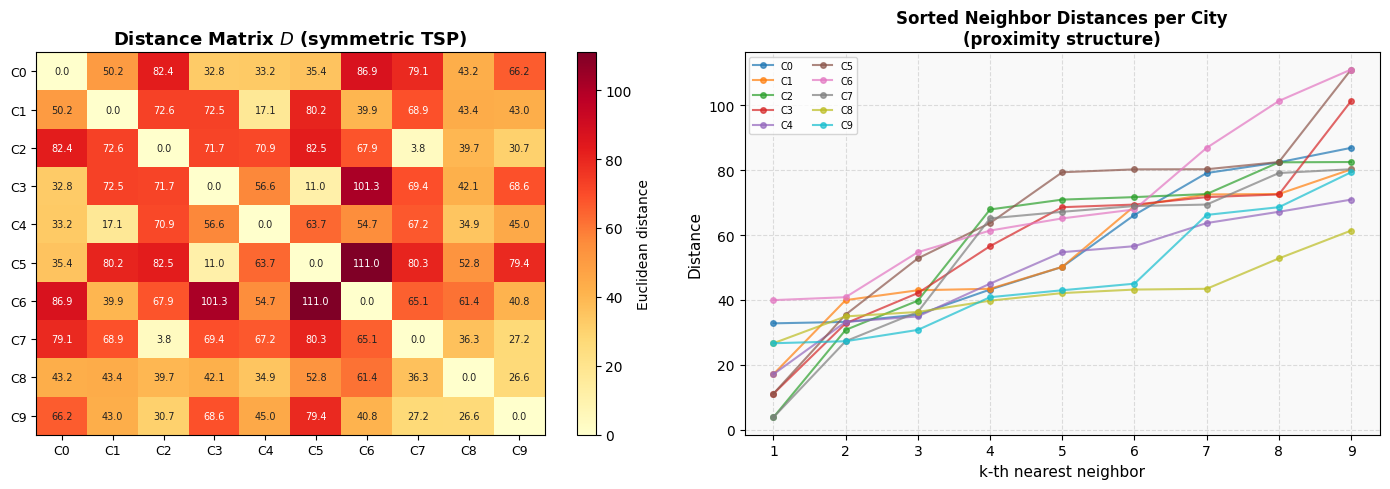

Saved → figures/tsp_distance_matrix.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: full distance matrix heatmap ──────────────────────────────────────
ax = axes[0]
im = ax.imshow(dist_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Euclidean distance')

ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(city_names, fontsize=9)
ax.set_yticklabels(city_names, fontsize=9)
ax.set_title('Distance Matrix $D$ (symmetric TSP)', fontsize=13, fontweight='bold')

# annotate each cell
for i in range(N):
    for j in range(N):
        val = dist_matrix[i, j]
        text_color = 'white' if val > dist_matrix.max() * 0.6 else '#222'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=7, color=text_color)

# ── Right: sorted nearest-neighbor distances per city ───────────────────────
ax2 = axes[1]
sorted_dists = np.sort(dist_matrix + np.eye(N) * 1e9, axis=1)[:, :N-1]

for i in range(N):
    ax2.plot(range(1, N), sorted_dists[i],
             marker='o', markersize=4, alpha=0.7, label=city_names[i])

ax2.set_xlabel('k-th nearest neighbor', fontsize=11)
ax2.set_ylabel('Distance', fontsize=11)
ax2.set_title('Sorted Neighbor Distances per City\n(proximity structure)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, N))
ax2.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.8)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('figures/tsp_distance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/tsp_distance_matrix.png')


## 6. Cấu trúc Lân cận — 2-opt Neighborhood

**2-opt swap** là phép hoán vị lân cận phổ biến nhất trong TSP.  
Cho hai vị trí $i < j$ trong tour, ta **đảo ngược** đoạn con $[i, j]$:

$$\text{Before: } \ldots \to a \to \underbrace{c_i \to \cdots \to c_j}_{\text{sub-tour}} \to b \to \ldots$$
$$\text{After: } \ldots \to a \to \underbrace{c_j \to \cdots \to c_i}_{\text{reversed}} \to b \to \ldots$$

Mỗi hoán vị 2-opt tạo ra một **tour lân cận hợp lệ** (vẫn là hoán vị đầy đủ). Kích thước vùng lân cận: $\binom{n}{2} = \frac{n(n-1)}{2}$ láng giềng.

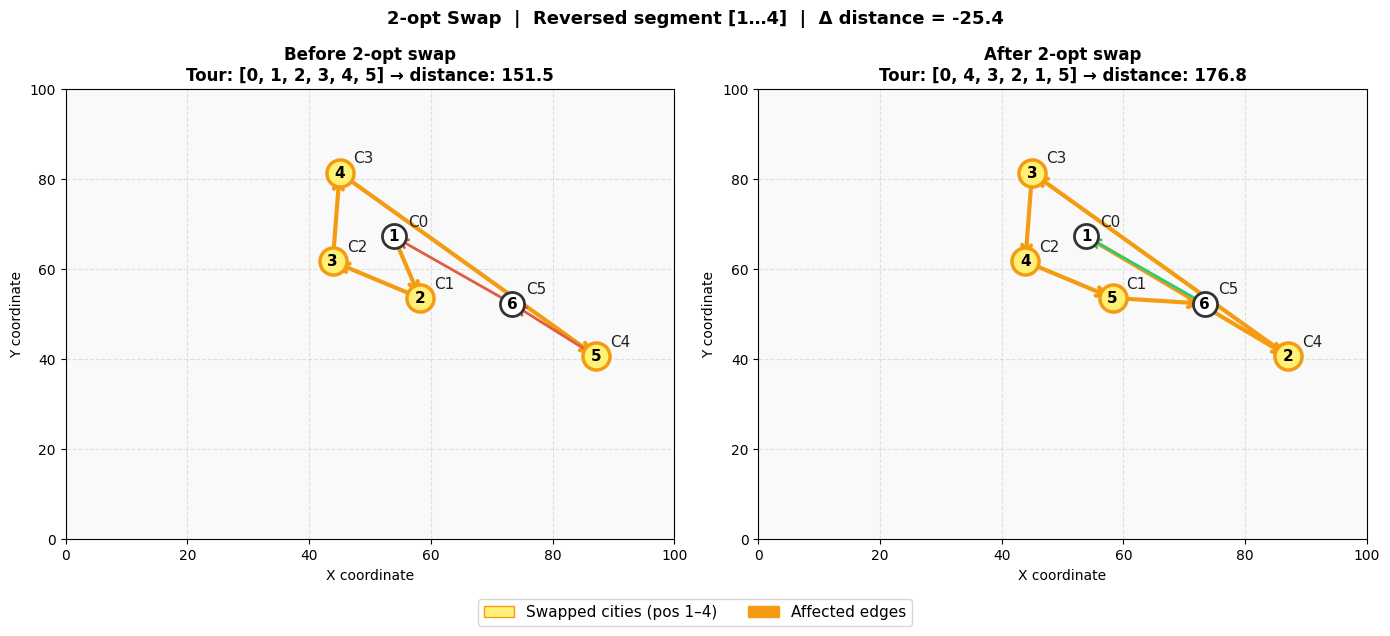

Saved → figures/tsp_2opt_swap.png
Before: [0, 1, 2, 3, 4, 5]  d = 151.5
After:  [0, 4, 3, 2, 1, 5]  d = 176.8
Change: -25.4


In [7]:
# Use 6-city sub-problem for clarity
np.random.seed(0)
sub_n = 6
sub_coords = np.random.rand(sub_n, 2) * 80 + 10
sub_names = [f'C{i}' for i in range(sub_n)]

# Seed tour and its 2-opt improvement
before_tour = [0, 1, 2, 3, 4, 5]   # some tour
swap_i, swap_j = 1, 4              # swap positions 1..4
after_tour = before_tour[:swap_i] + before_tour[swap_i:swap_j+1][::-1] + before_tour[swap_j+1:]

sub_dist = np.sqrt(((sub_coords[:, None, :] - sub_coords[None, :, :]) ** 2).sum(axis=-1))
d_before = tour_length(sub_dist, before_tour)
d_after  = tour_length(sub_dist, after_tour)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tour, title, main_color in [
    (axes[0], before_tour, 'Before 2-opt swap', '#e05c42'),
    (axes[1], after_tour,  'After 2-opt swap',  '#2ecc71'),
]:
    n_s = len(tour)
    for k in range(n_s):
        ci, cj = tour[k], tour[(k+1) % n_s]
        xi, yi = sub_coords[ci]
        xj, yj = sub_coords[cj]
        # Highlight the swapped segment edges
        is_swapped_edge = (
            (k >= swap_i - 1 and k < swap_j) or
            (k == swap_j and title.startswith('After'))
        )
        color = '#f39c12' if is_swapped_edge else main_color
        lw = 3.0 if is_swapped_edge else 2.0
        ax.annotate('', xy=(xj, yj), xytext=(xi, yi),
                    arrowprops=dict(arrowstyle='->', color=color,
                                    lw=lw, mutation_scale=16))

    ax.scatter(sub_coords[:, 0], sub_coords[:, 1],
               s=300, c='white', edgecolors='#333', linewidths=2, zorder=6)
    order_map = {city: idx for idx, city in enumerate(tour)}
    for i, (x, y) in enumerate(sub_coords):
        ax.text(x, y, str(order_map[i] + 1), ha='center', va='center',
                fontsize=11, fontweight='bold', zorder=9)
        ax.annotate(sub_names[i], (x, y),
                    textcoords='offset points', xytext=(10, 7),
                    fontsize=11, color='#222')

    # Highlight swapped cities
    for idx in range(swap_i, swap_j + 1):
        ax.scatter(*sub_coords[before_tour[idx]],
                   s=380, c='#fff176', edgecolors='#f39c12',
                   linewidths=2.5, zorder=7)

    dist = tour_length(sub_dist, tour)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_title(f'{title}\nTour: {tour} → distance: {dist:.1f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_facecolor('#f9f9f9')

# Legend
yellow_patch = mpatches.Patch(color='#fff176', ec='#f39c12', label=f'Swapped cities (pos {swap_i}–{swap_j})')
orange_line  = mpatches.Patch(color='#f39c12', label='Affected edges')
fig.legend(handles=[yellow_patch, orange_line], loc='lower center',
           ncol=2, fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.06))

delta = d_before - d_after
fig.suptitle(f'2-opt Swap  |  Reversed segment [{swap_i}…{swap_j}]'
             f'  |  Δ distance = {delta:+.1f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/tsp_2opt_swap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → figures/tsp_2opt_swap.png')
print(f'Before: {before_tour}  d = {d_before:.1f}')
print(f'After:  {after_tour}  d = {d_after:.1f}')
print(f'Change: {delta:+.1f}')


## 7. Tổng hợp — Summary

| Thuộc tính | Giá trị |
|---|---|
| **Thuộc loại** | Discrete Optimization — Combinatorial |
| **Dữ liệu đầu vào** | Ma trận khoảng cách $D_{n \times n}$ |
| **Biểu diễn nghiệm** | Hoán vị $\mathbf{x} = (x_1, \ldots, x_n)$ |
| **Kích thước không gian** | $(n-1)!/2$ tour phân biệt |
| **Hàm mục tiêu** | $\min \sum_{i}\sum_{j} d_{ij} x_{ij}$ |
| **Ràng buộc** | Mỗi thành phố thăm đúng 1 lần (chu trình Hamiltonian) |
| **Phép lân cận phổ biến** | 2-opt swap, 3-opt, Or-opt |
| **NP-hardness** | NP-Hard (không có thuật toán đa thức optimal đã biết) |